Tarea 3 — Análisis Exploratorio y Métricas (EDA)
En un Jupyter Notebook (analysis.ipynb), realiza un análisis exploratorio del
dataset y de los resultados de validación.

Distribución de montos: histograma, percentiles p50/p90/p99, detección de outliers

Análisis temporal: volumen de transacciones por hora del día y día de la semana

Tasa de rechazo por regla: ¿qué regla genera más rechazos? ¿hay correlación entre
reglas?

Perfil de cuentas riesgosas: agrupar por account_id y calcular métricas agregadas

Recall vs. is_flagged: comparar el campo is_flagged del dataset con el resultado del
motor; calcular precision, recall y F1 del motor de reglas

Mínimo 5 visualizaciones con matplotlib, seaborn o plotly
Incluir sección de hallazgos y recomendaciones en Markdown

In [2]:
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("data/validation_results.csv")

df.head()

,transaction_id,account_id,amount,currency,transaction_type,timestamp,country_code,merchant_category,account_age_days,daily_tx_count,is_flagged,balance_before,transaction_date,daily_total_amount,validation_status,violations
0,4e59b45b-cdac-45d2-bdfa-8ff04596a3bc,4322463c-165a-4983-81db-71e95bdee472,74155.31,USD,TRANSFER,2025-01-03T16:51:18+00:00,FR,restaurant,286,1,False,48978.37,2025-01-03,128086.30,REJECTED,"[{""rule_id"": ""RG-002"", ""severity"": ""HIGH"", ""ac..."
1,af081926-6aa1-4703-8a55-f5275f672fac,d2a709b7-573d-4231-9127-677224bbc21d,56124.95,EUR,TRANSFER,2025-01-06T15:32:05+00:00,US,healthcare,1437,1,False,143203.92,2025-01-06,56124.95,REJECTED,"[{""rule_id"": ""RG-002"", ""severity"": ""HIGH"", ""ac..."
2,406d014c-f5f0-41de-9199-9aa14371db6e,c2703a5d-f877-434d-a311-a724f5223ab6,15548.79,EUR,WITHDRAWAL,2025-01-09T06:12:37+00:00,FR,restaurant,690,1,False,191442.61,2025-01-09,55896.57,REJECTED,"[{""rule_id"": ""RG-002"", ""severity"": ""HIGH"", ""ac..."
3,2f6d652f-8625-4efb-9cb0-c6a2b95a657e,377a1f5f-91ae-4f58-ba34-cbad83cff81d,7880.94,DOP,DEPOSIT,2025-01-04T00:42:59+00:00,DO,luxury_goods,1288,1,False,58635.66,2025-01-04,150644.91,REJECTED,"[{""rule_id"": ""RG-002"", ""severity"": ""HIGH"", ""ac..."
4,b4487dbb-e45e-49f6-859f-17f4d782355d,5d31a5b3-9aab-4d45-95ed-5b32cf3903d3,86648.50,EUR,PAYMENT,2025-01-02T22:28:55+00:00,DO,crypto_exchange,929,1,False,76025.25,2025-01-02,260648.13,REJECTED,"[{""rule_id"": ""RG-002"", ""severity"": ""HIGH"", ""ac..."


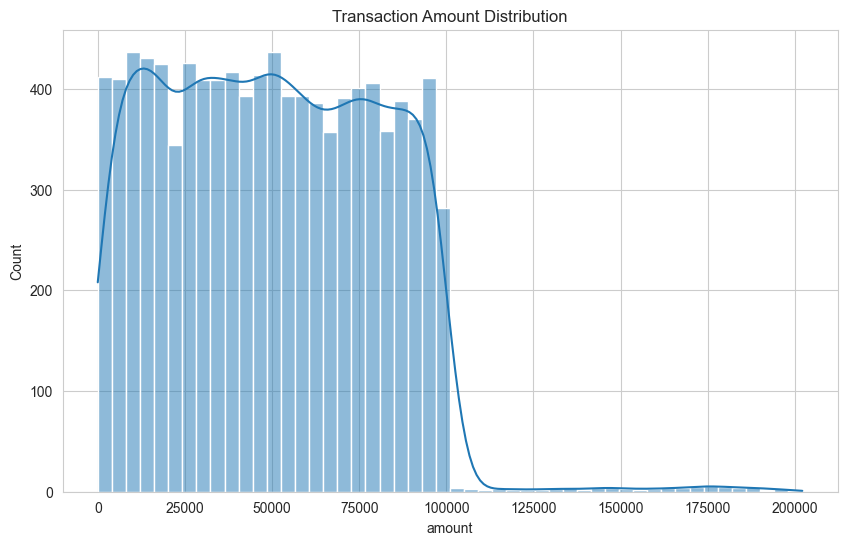

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["amount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

La mayoría de las transacciones manejan montos bajos o moderados, mientras que solo unas pocas alcanzan valores altos. Esto es algo común en sistemas financieros, aunque esos casos extremos pueden ser señales importantes y vale la pena monitorearlos más de cerca.

In [5]:
p50 = df["amount"].quantile(0.50)
p90 = df["amount"].quantile(0.90)
p99 = df["amount"].quantile(0.99)

print(f"P50: {p50:.2f}")
print(f"P90: {p90:.2f}")
print(f"P99: {p99:.2f}")

P50: 49082.86
P90: 90497.40
P99: 99737.55


P50 -> La mediana.
50% de transacciones son menores que eso.

P90 -> El 90% está debajo de ese valor.

P99 -> Transacciones extremadamente altas.


<Axes: xlabel='amount'>

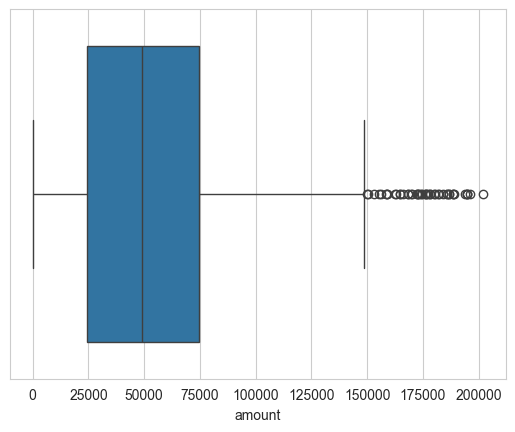

In [6]:
sns.boxplot(x=df["amount"])

Se encontraron algunas transacciones con montos mucho más altos que el promedio. Aunque pueden ser operaciones normales, también podrían indicar comportamientos fuera de lo común, por lo que conviene analizarlas con más detalle.